# Spread Spectrum: A Simulation Study

#### Imports and plot setup

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch


#### Imports and frequency grid

In [61]:

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True

df    = 1.0                          # frequency resolution [Hz]
f_max = 15_000.0                     # grid half-span [Hz] — must exceed 50+10000
f = np.arange(-f_max, f_max + df, df)
print(f"Frequency grid: {f.size} points, resolution {df} Hz, span ±{f_max/1e3:.0f} kHz")

Frequency grid: 30001 points, resolution 1.0 Hz, span ±15 kHz


## Narrowband spectrum X(f), band-limited to ±50 Hz

Total power of X (check) : 1.0000
Peak PSD height of X     : 0.010526
Expected 1/(2*B_narrow)  : 0.010000


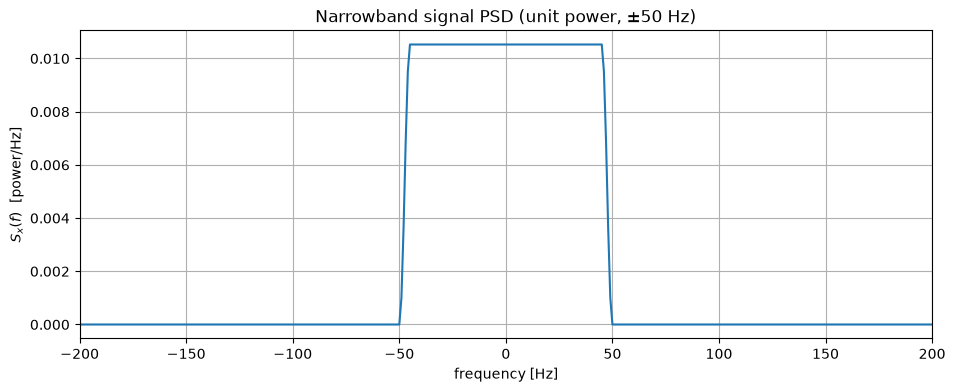

In [62]:
def raised_cosine_psd(f, B, roll=0.1, power=1.0):
    """Band-limited PSD shape, normalized so total power = `power`."""
    edge = roll * B
    mag = np.zeros_like(f)
    flat  = np.abs(f) <= (B - edge)
    trans = (np.abs(f) > (B - edge)) & (np.abs(f) <= B)
    mag[flat]  = 1.0
    mag[trans] = 0.5 * (1 + np.cos(np.pi * (np.abs(f[trans]) - (B - edge)) / edge))

    area = np.trapezoid(mag, f)    
    return mag * (power / area)          # rescale so ∫ PSD df = power

B_narrow = 50.0
Sx = raised_cosine_psd(f, B_narrow, roll=0.1, power=1.0)

print(f"Total power of X (check) : {np.trapezoid(Sx, f):.4f}")
print(f"Peak PSD height of X     : {Sx.max():.6f}")
print(f"Expected 1/(2*B_narrow)  : {1/(2*B_narrow):.6f}")

plt.plot(f, Sx)
plt.xlim(-200, 200)
plt.xlabel("frequency [Hz]"); plt.ylabel(r"$S_x(f)$  [power/Hz]")
plt.title("Narrowband signal PSD (unit power, ±50 Hz)")
plt.show()

#### Wideband spreading spectrum C(f), flat over ±10 kHz

Total power of C (check) : 1.0000
Peak PSD height of C     : 0.000051
Expected 1/(2*B_wide)    : 0.000050


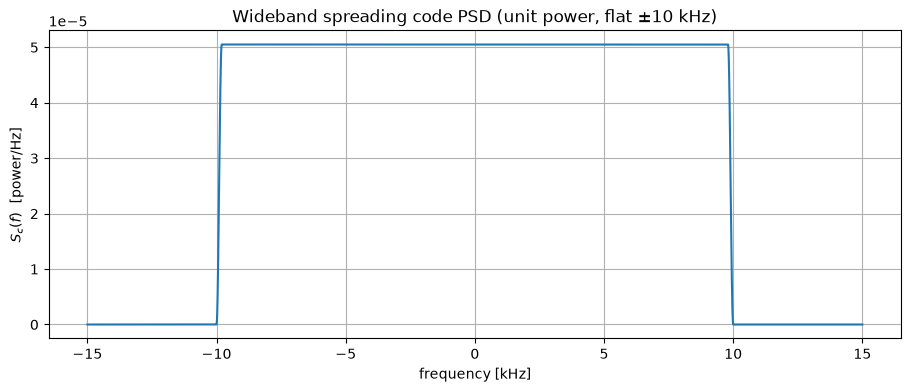

In [63]:
B_wide = 10_000.0
Sc = raised_cosine_psd(f, B_wide, roll=0.02, power=1.0)

print(f"Total power of C (check) : {np.trapezoid(Sc, f):.4f}")
print(f"Peak PSD height of C     : {Sc.max():.6f}")
print(f"Expected 1/(2*B_wide)    : {1/(2*B_wide):.6f}")

plt.plot(f/1e3, Sc)
plt.xlabel("frequency [kHz]"); plt.ylabel(r"$S_c(f)$  [power/Hz]")
plt.title("Wideband spreading code PSD (unit power, flat ±10 kHz)")
plt.show()

### Build the unspread and spread waveforms

Peak PSD before spreading  : 0.010526
Peak PSD after spreading   : 0.000051
Ratio (after / before)     : 0.00480
Expected B_narrow/B_wide   : 0.00500
Total power after (check)  : 1.0000   (should stay ≈ 1)


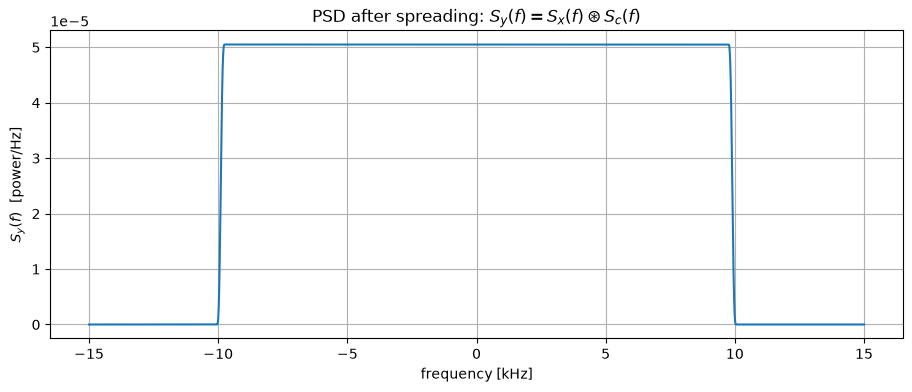

In [64]:
Sy = np.convolve(Sx, Sc, mode="same") * df

print(f"Peak PSD before spreading  : {Sx.max():.6f}")
print(f"Peak PSD after spreading   : {Sy.max():.6f}")
print(f"Ratio (after / before)     : {Sy.max()/Sx.max():.5f}")
print(f"Expected B_narrow/B_wide   : {B_narrow/B_wide:.5f}")
print(f"Total power after (check)  : {np.trapezoid(Sy, f):.4f}   (should stay ≈ 1)")

plt.plot(f/1e3, Sy)
plt.xlabel("frequency [kHz]"); plt.ylabel(r"$S_y(f)$  [power/Hz]")
plt.title(r"PSD after spreading: $S_y(f) = S_x(f) \circledast S_c(f)$")
plt.show()

**Despreading**

max|x - z| (should be ~0)  : 0.00e+00
power(x)                   : 1.0020
power(z)                   : 1.0020


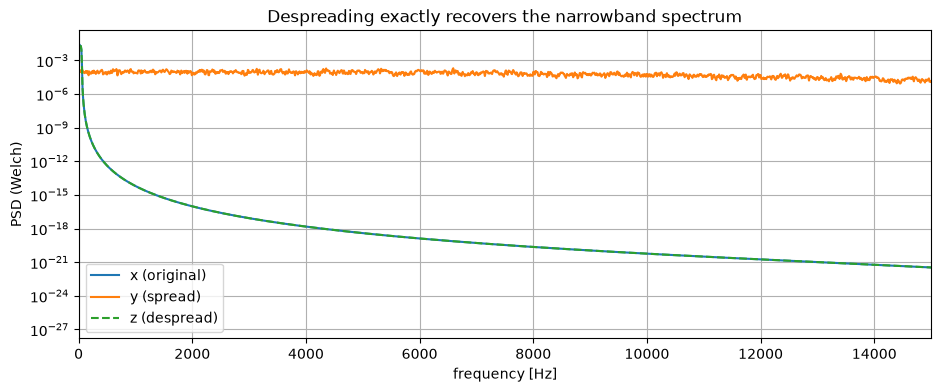

In [65]:
# ---- Time-domain realization ----
fs = 40_000.0                      # sample rate [Hz] (must exceed 2*f_max)
T  = 1.0                           # duration [s] -> freq resolution 1/T = 1 Hz, matches df
N  = int(fs * T)
t  = np.arange(N) / fs

rng = np.random.default_rng(0)

def colored_noise(psd_func, N, fs, rng):
    """Real noise whose PSD matches psd_func evaluated at the FFT bin frequencies."""
    freqs = np.fft.rfftfreq(N, 1 / fs)
    shape = np.sqrt(psd_func(freqs))
    X = np.fft.rfft(rng.standard_normal(N)) * shape
    x = np.fft.irfft(X, N)
    return x / x.std()             # normalize to unit power

# Narrowband message x(t): PSD matches Sx (±50 Hz)
x = colored_noise(lambda ff: raised_cosine_psd(ff, B_narrow, roll=0.1, power=1.0), N, fs, rng)

# PN spreading code c(t): random ±1 chips. Chip rate is chosen so the code's
# (sinc-shaped) spectrum has its main lobe out to about B_wide.
Rc  = 2 * B_wide                     # chip rate [chips/s]
spc = max(1, int(round(fs / Rc)))    # samples per chip
n_chips = N // spc + 1
chips = rng.choice([-1.0, 1.0], size=n_chips)
c = np.repeat(chips, spc)[:N]

y = x * c                            # ---- SPREAD ----
z = y * c                            # ---- DESPREAD: c(t)**2 == 1 exactly, so z(t) == x(t) ----

print(f"max|x - z| (should be ~0)  : {np.max(np.abs(x - z)):.2e}")
print(f"power(x)                   : {np.mean(x**2):.4f}")
print(f"power(z)                   : {np.mean(z**2):.4f}")

f_w, Px = welch(x, fs=fs, nperseg=4096)
f_w, Py = welch(y, fs=fs, nperseg=4096)
f_w, Pz = welch(z, fs=fs, nperseg=4096)

plt.semilogy(f_w, Px, label="x (original)")
plt.semilogy(f_w, Py, label="y (spread)")
plt.semilogy(f_w, Pz, "--", label="z (despread)")
plt.xlim(0, B_wide * 1.5)
plt.xlabel("frequency [Hz]"); plt.ylabel("PSD (Welch)")
plt.title("Despreading exactly recovers the narrowband spectrum")
plt.legend()
plt.show()


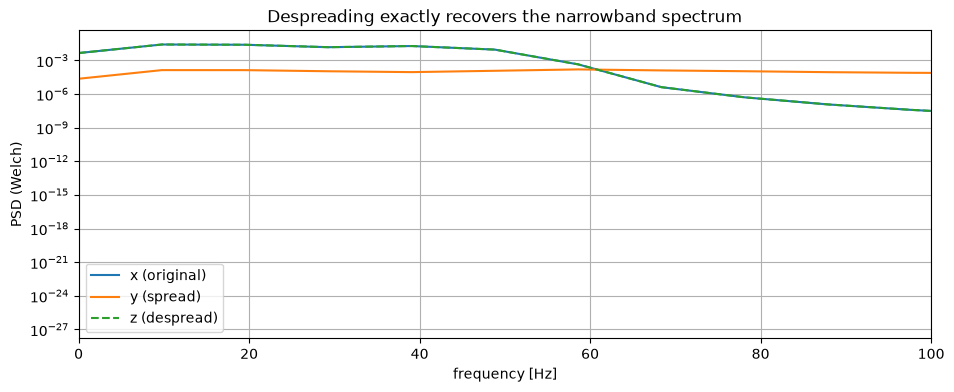

In [66]:
plt.semilogy(f_w, Px, label="x (original)")
plt.semilogy(f_w, Py, label="y (spread)")
plt.semilogy(f_w, Pz, "--", label="z (despread)")
plt.xlim(0, 100)
plt.xlabel("frequency [Hz]"); plt.ylabel("PSD (Welch)")
plt.title("Despreading exactly recovers the narrowband spectrum")
plt.legend()
plt.show()

**Bury it in noise, then dig it out**

SNR before despreading (dB): -23.0 dB


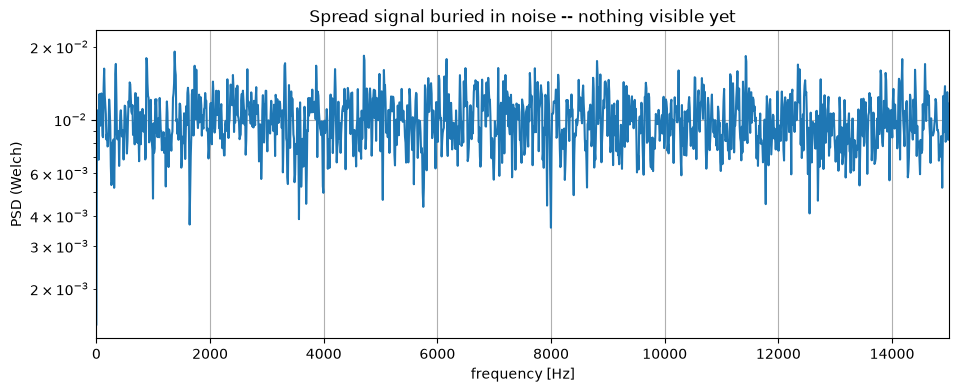

In [67]:
# ---- Bury the spread signal in noise ----
noise_power_ratio = 200          # noise power this many times stronger than the spread signal
noise = rng.standard_normal(N)
noise *= np.sqrt(noise_power_ratio * np.mean(y**2) / np.mean(noise**2))

y_noisy = y + noise

print(f"SNR before despreading (dB): {10*np.log10(np.mean(y**2)/np.mean(noise**2)):.1f} dB")

f_w, Py_noisy = welch(y_noisy, fs=fs, nperseg=4096)
plt.semilogy(f_w, Py_noisy)
plt.xlim(0, B_wide * 1.5)
plt.xlabel("frequency [Hz]"); plt.ylabel("PSD (Welch)")
plt.title("Spread signal buried in noise -- nothing visible yet")
plt.show()


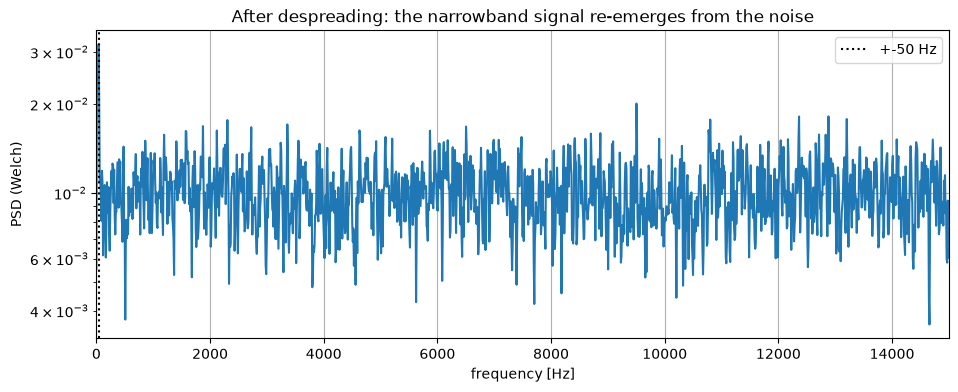

In [68]:
# ---- Despread: multiply by the same code again ----
z_noisy = y_noisy * c        # = x + noise*c  (x collapses back to +-50 Hz; noise stays wideband)

f_w, Pz_noisy = welch(z_noisy, fs=fs, nperseg=4096)
plt.semilogy(f_w, Pz_noisy)
plt.xlim(0, B_wide * 1.5)
plt.axvline(B_narrow, color="k", ls=":", label=f"+-{B_narrow:.0f} Hz")
plt.xlabel("frequency [Hz]"); plt.ylabel("PSD (Welch)")
plt.title("After despreading: the narrowband signal re-emerges from the noise")
plt.legend()
plt.show()


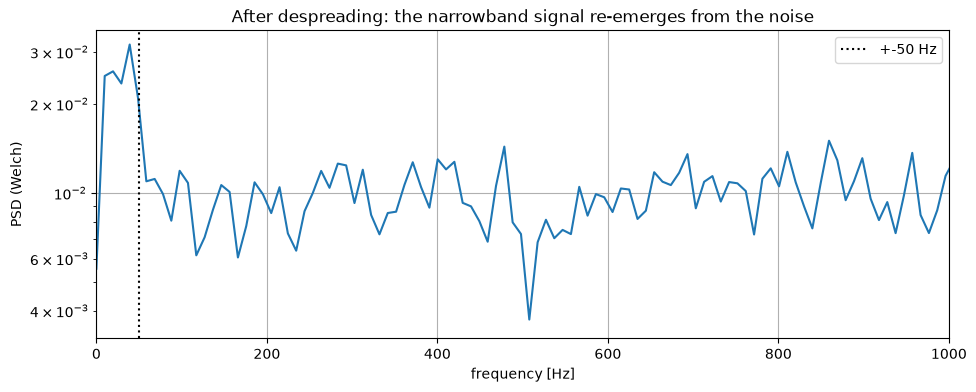

In [69]:
f_w, Pz_noisy = welch(z_noisy, fs=fs, nperseg=4096)
plt.semilogy(f_w, Pz_noisy)
plt.xlim(0, 1000)
plt.axvline(B_narrow, color="k", ls=":", label=f"+-{B_narrow:.0f} Hz")
plt.xlabel("frequency [Hz]"); plt.ylabel("PSD (Welch)")
plt.title("After despreading: the narrowband signal re-emerges from the noise")
plt.legend()
plt.show()

Correlation(x, x_hat): 0.4749


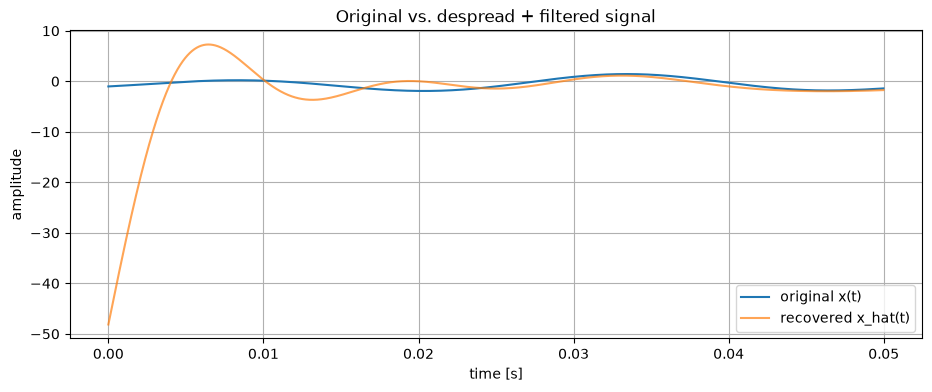

In [70]:
# ---- Final cleanup: lowpass filter matched to the message bandwidth ----
from scipy.signal import butter, filtfilt

b, a = butter(6, B_narrow * 1.5, fs=fs, btype="low")
x_hat = filtfilt(b, a, z_noisy)

print(f"Correlation(x, x_hat): {np.corrcoef(x, x_hat)[0, 1]:.4f}")

plt.plot(t[:2000], x[:2000], label="original x(t)")
plt.plot(t[:2000], x_hat[:2000], label="recovered x_hat(t)", alpha=0.7)
plt.xlabel("time [s]"); plt.ylabel("amplitude")
plt.title("Original vs. despread + filtered signal")
plt.legend()
plt.show()


## Jam the spread signal with a narrowband interferer


SIR before despreading (dB): -20.0 dB


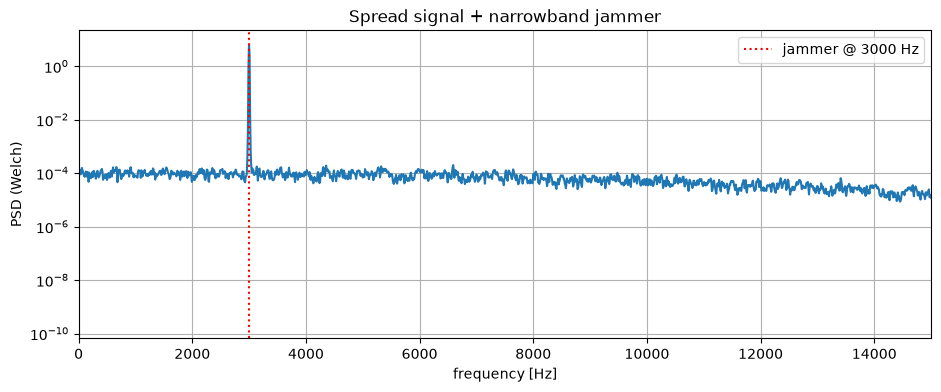

In [71]:
# ---- Jam the spread signal with a narrowband interferer ----
f_jam = 3000.0                      # jammer sits somewhere inside the spread band [Hz]
jam_power_ratio = 100                # jammer power this many times stronger than y

jam = np.cos(2 * np.pi * f_jam * t + rng.uniform(0, 2 * np.pi))
jam *= np.sqrt(jam_power_ratio * np.mean(y**2) / np.mean(jam**2))

y_jammed = y + jam

print(f"SIR before despreading (dB): {10*np.log10(np.mean(y**2)/np.mean(jam**2)):.1f} dB")

f_w, Py_jammed = welch(y_jammed, fs=fs, nperseg=4096)
plt.semilogy(f_w, Py_jammed)
plt.axvline(f_jam, color="r", ls=":", label=f"jammer @ {f_jam:.0f} Hz")
plt.xlim(0, B_wide * 1.5)
plt.xlabel("frequency [Hz]"); plt.ylabel("PSD (Welch)")
plt.title("Spread signal + narrowband jammer")
plt.legend()
plt.show()

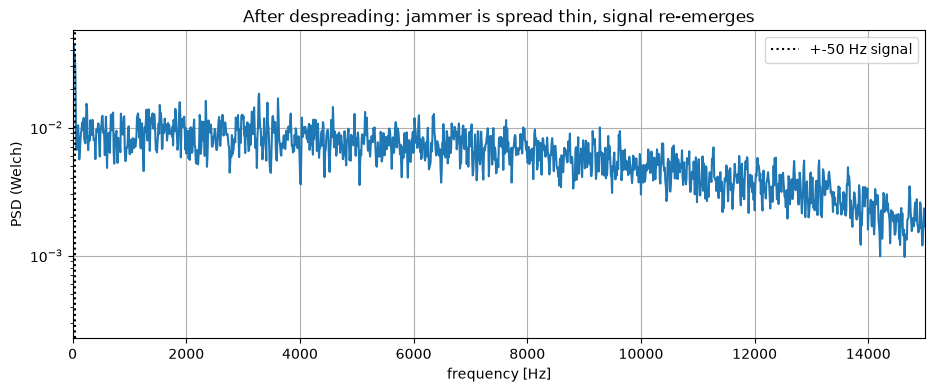

In [72]:
# ---- Despread: c(t) undoes the spreading on x, but the jammer was never
#      coded, so multiplying it by c(t) now SPREADS the jammer instead ----
z_jammed = y_jammed * c        # = x + jam*c   (x -> +-B_narrow ; jam*c -> spread over B_wide)

f_w, Pz_jammed = welch(z_jammed, fs=fs, nperseg=4096)
plt.semilogy(f_w, Pz_jammed)
plt.axvline(B_narrow, color="k", ls=":", label=f"+-{B_narrow:.0f} Hz signal")
plt.xlim(0, B_wide * 1.5)
plt.xlabel("frequency [Hz]"); plt.ylabel("PSD (Welch)")
plt.title("After despreading: jammer is spread thin, signal re-emerges")
plt.legend()
plt.show()

Correlation(x, x_hat_jam): 0.8292


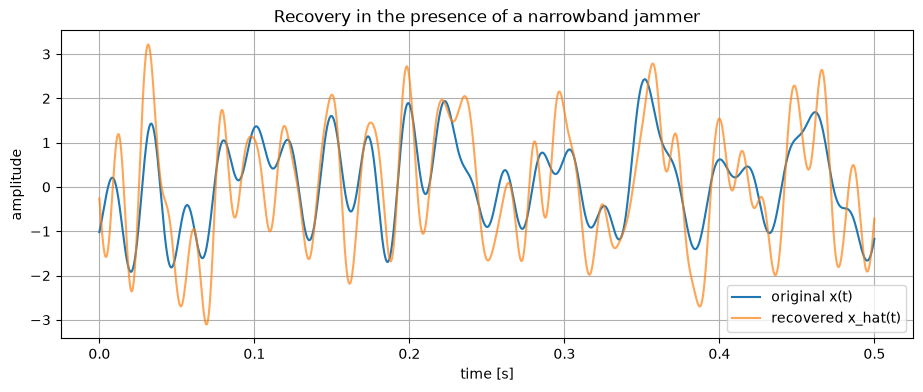

In [73]:
# ---- Lowpass filter mops up what's left of the now-wideband jammer ----
from scipy.signal import butter, filtfilt

b, a = butter(6, B_narrow * 1.5, fs=fs, btype="low")
x_hat_jam = filtfilt(b, a, z_jammed)

print(f"Correlation(x, x_hat_jam): {np.corrcoef(x, x_hat_jam)[0, 1]:.4f}")

plt.plot(t[:20000], x[:20000], label="original x(t)")
plt.plot(t[:20000], x_hat_jam[:20000], label="recovered x_hat(t)", alpha=0.7)
plt.xlabel("time [s]"); plt.ylabel("amplitude")
plt.title("Recovery in the presence of a narrowband jammer")
plt.legend()
plt.show()